In [1]:
# Required Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
# Dataset
df = pd.read_csv("cleaned_brain_measures.csv")
df.head()

,ID,Bvol,GMvol,WMvol,Ribbon,Thickness,AgeGroup,Sex,Age,Database,FAvol,FAM,FAPVE,MDvol,MDM,MDPVE
0,1,867,1741547.000,724333.490,693513.524,2.828992,25-29Years3T,M,24.4,MCBI1,800985.1875,0.410045,328439.971208,809482.3125,0.000591,478.404046
1,2,872,1397434.000,585816.909,526163.247,NaN,20-24Years3T,F,41,MCBI1,571318.4375,0.309419,176776.779612,577600.8125,0.000669,386.414943
2,3,873,1454708.375,610216.338,559222.751,NaN,30-34Years3T,F,30,MCBI1,627039.5000,0.333543,209144.635948,634184.2500,0.000642,407.146288
3,4,874,1723251.000,712120.587,633187.458,2.812118,30-34Years3T,M,30.8,MCBI1,730697.7500,0.402288,293950.936452,737267.5000,0.000605,446.046837
4,5,875,1423791.000,595047.068,548548.729,NaN,20-24Years3T,F,28,MCBI1,662103.3750,0.328814,217708.859147,664786.6875,0.000694,461.361961


In [4]:
df['Sex'].unique()

array(['M', 'F', 'NotReported'], dtype=object)

In [5]:
# Standardize and clean 'Sex' column
df['Sex'] = df['Sex'].str.strip().str.upper()

# Replace unexpected values with NaN
df['Sex'] = df['Sex'].replace(['UNKNOWN', '', 'NA', 'N/A'], np.nan)

# Drop or impute rows with invalid/missing sex (if few)
df = df[df['Sex'].isin(['M', 'F'])]

# Encode Sex (0 = Female, 1 = Male)
from sklearn.preprocessing import LabelEncoder
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

In [6]:
df['Sex'].unique()

array([1, 0])

In [7]:
df['AgeGroup'].unique()

array(['25-29Years3T', '20-24Years3T', '30-34Years3T', '65-69Years3T',
       '4-5Months', '6-0Months', '7-5Months', '10-5Years', '9-0Years',
       '12-5Years', '12-0Years', '7-0Years', '8-5Years3T', '7-5Years3T',
       '6-5Years', '11-5Years', '7-0Years3T', '15-5Years', '11-0Years',
       '13-0Years', '9-5Years', '14-0Years', '5-5Years3T', '17-0Years',
       '15-0Years', '8-5Years', '9-0Years3T', '8-0Years', '14-5Years3T',
       '16-0Years', '6-0Years', '7-5Years', '6-5Years3T', '5-5Years',
       '13-5Years3T', '18-5Years', '14-5Years', '16-5Years', '13-5Years',
       '3-5Years', '18-0Years', '19-0Years', '19-5Years', '20-24Years',
       '17-5Years', '10-0Years', '3-0Years', '5-0Years', '4-5Years',
       '4-0Years', '5-0Years3T', '6-0Years3T', '25-29Years', '30-34Years',
       '12-0Months', '15-0Months', '10-5Months', '12-0Months3T',
       '2-0Years', '18-0Months', '2-0Weeks', '1-0Months', '2-0Months',
       '3-0Months', '9-0Months', '2-0Years3T', '6-0Months3T',
       '4-

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6145 entries, 0 to 6148
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         6145 non-null   int64  
 1   Bvol       6145 non-null   int64  
 2   GMvol      6139 non-null   float64
 3   WMvol      6137 non-null   float64
 4   Ribbon     6142 non-null   object 
 5   Thickness  5611 non-null   float64
 6   AgeGroup   6145 non-null   object 
 7   Sex        6145 non-null   int64  
 8   Age        6145 non-null   object 
 9   Database   6145 non-null   object 
 10  FAvol      6145 non-null   float64
 11  FAM        6145 non-null   float64
 12  FAPVE      6145 non-null   float64
 13  MDvol      6145 non-null   float64
 14  MDM        6145 non-null   float64
 15  MDPVE      6145 non-null   float64
dtypes: float64(9), int64(3), object(4)
memory usage: 816.1+ KB


In [9]:
df.isnull().sum()

ID             0
Bvol           0
GMvol          6
WMvol          8
Ribbon         3
Thickness    534
AgeGroup       0
Sex            0
Age            0
Database       0
FAvol          0
FAM            0
FAPVE          0
MDvol          0
MDM            0
MDPVE          0
dtype: int64

In [10]:
df.shape

(6145, 16)

In [11]:
# Age to Numeric and Filter Children ≤12
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df = df[df['Age'] <= 12].copy()

In [12]:
# Encoding Categorical Variables
df['Sex'] = LabelEncoder().fit_transform(df['Sex'].astype(str))
df['AgeGroup'] = df['AgeGroup'].fillna('Unknown')
df['AgeGroupEncoded'] = LabelEncoder().fit_transform(df['AgeGroup'])
df['Ribbon'] = df['Ribbon'].fillna('Unknown')
df['RibbonEncoded'] = LabelEncoder().fit_transform(df['Ribbon'])

In [13]:
# Missing Values (mean imputation for numeric columns)
cols_to_impute = ['GMvol', 'WMvol', 'Thickness']
imputer = SimpleImputer(strategy='mean')
df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])

In [14]:
# 🔹 6. Select Features for Clustering
features = ['Bvol', 'GMvol', 'WMvol', 'Thickness', 'FAvol', 'FAM', 'FAPVE',
            'MDvol', 'MDM', 'MDPVE', 'Sex', 'AgeGroupEncoded', 'RibbonEncoded']

In [15]:
X = df[features]

In [16]:
# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

In [17]:
X_scaled_df.head()

,Bvol,GMvol,WMvol,Thickness,FAvol,FAM,FAPVE,MDvol,MDM,MDPVE,Sex,AgeGroupEncoded,RibbonEncoded
0,-1.264434,-0.738008,-0.800948,1.970078,-0.008089,-0.896364,-0.578644,-0.014179,0.851951,0.910152,0.964644,0.142655,-0.866621
1,-1.264128,-0.850796,-1.392998,2.035593,0.124224,-0.880130,-0.487443,0.117884,0.826954,1.040517,0.964644,0.533268,-0.369766
2,-1.263822,-0.554094,-0.551123,2.130472,0.174871,-0.538095,-0.206413,0.168436,0.761053,1.013696,0.964644,0.533268,-0.638627
3,-1.263516,-0.953975,-0.862795,2.045368,-0.414087,-0.683843,-0.701931,-0.419411,0.740601,0.292462,-1.036651,0.533268,-1.060201
4,-1.262904,-0.837347,-0.697882,2.057221,-0.121147,-0.605316,-0.457505,-0.127024,0.799685,0.708102,-1.036651,0.533268,-1.006429


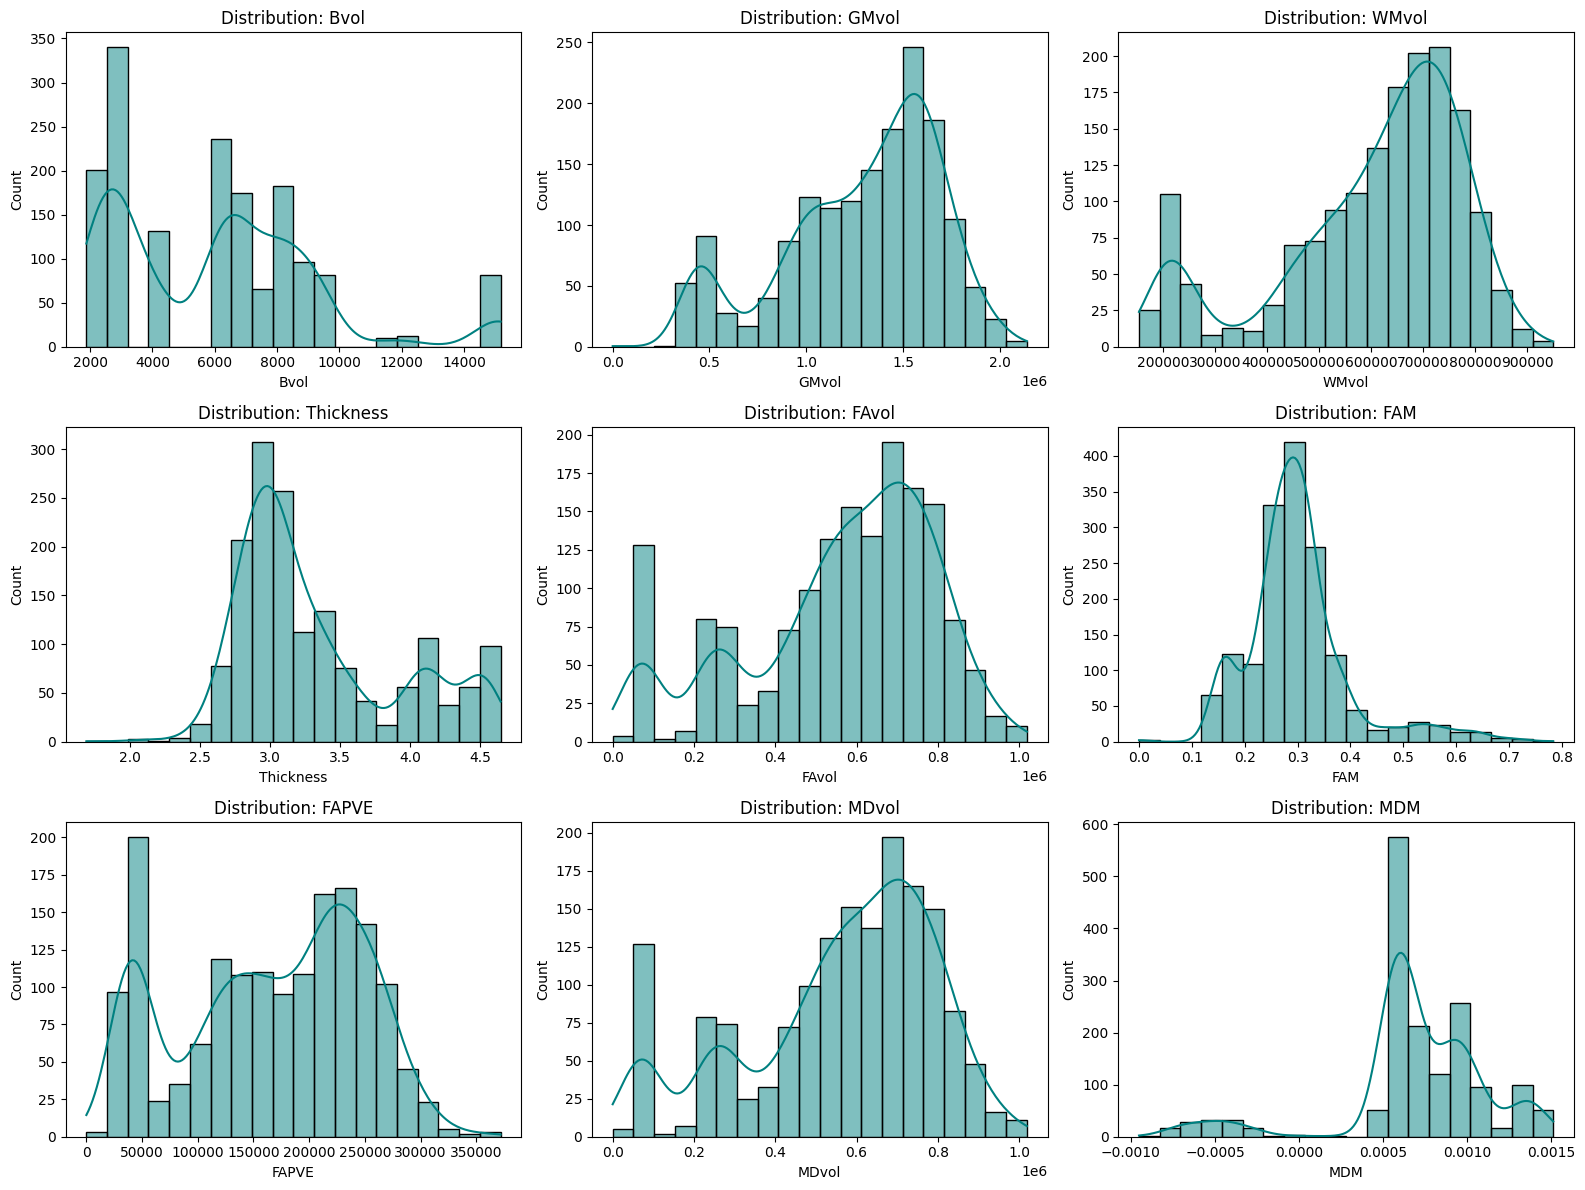

In [18]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(features[:9]):  # First 9 features
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, bins=20, color='teal')
    plt.title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

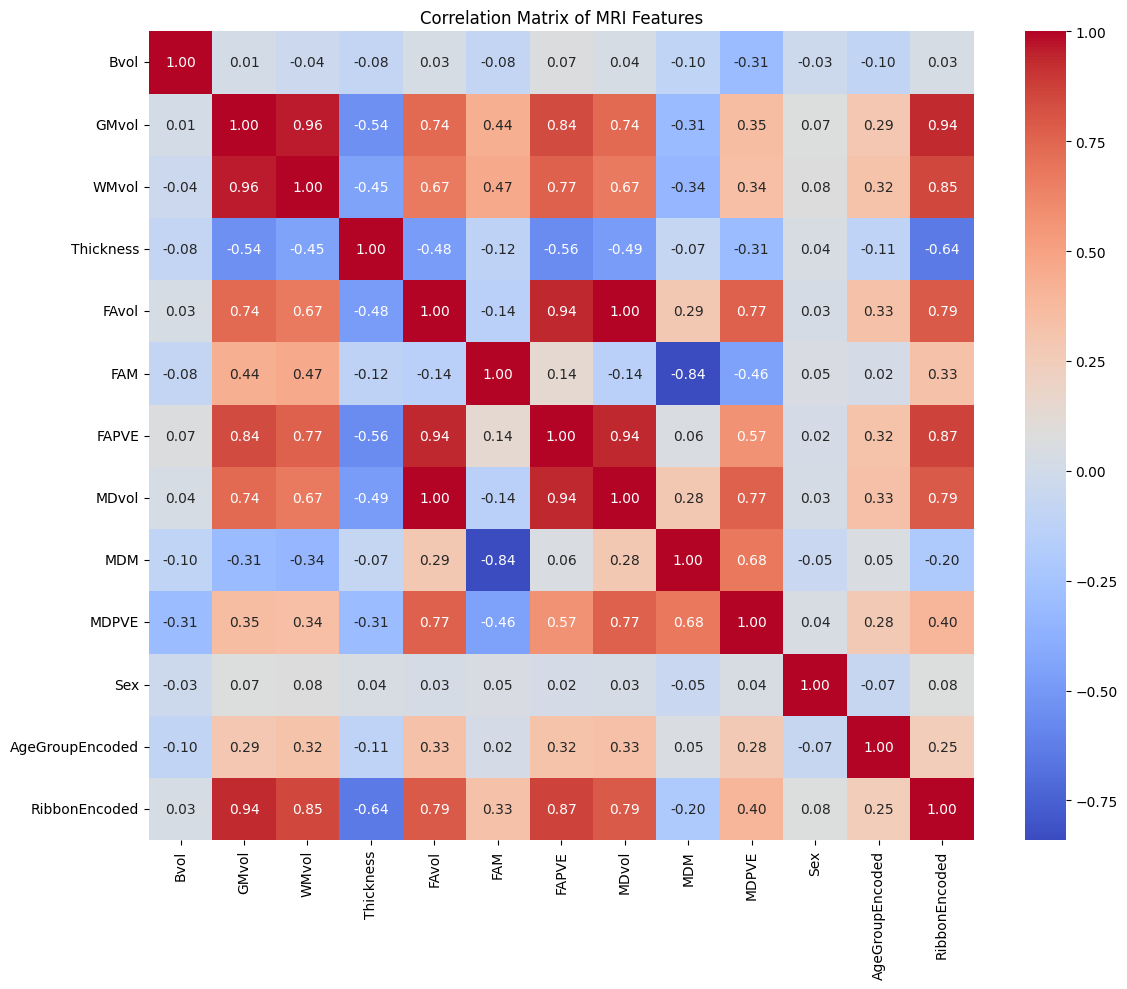

In [19]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of MRI Features")
plt.tight_layout()
plt.show()

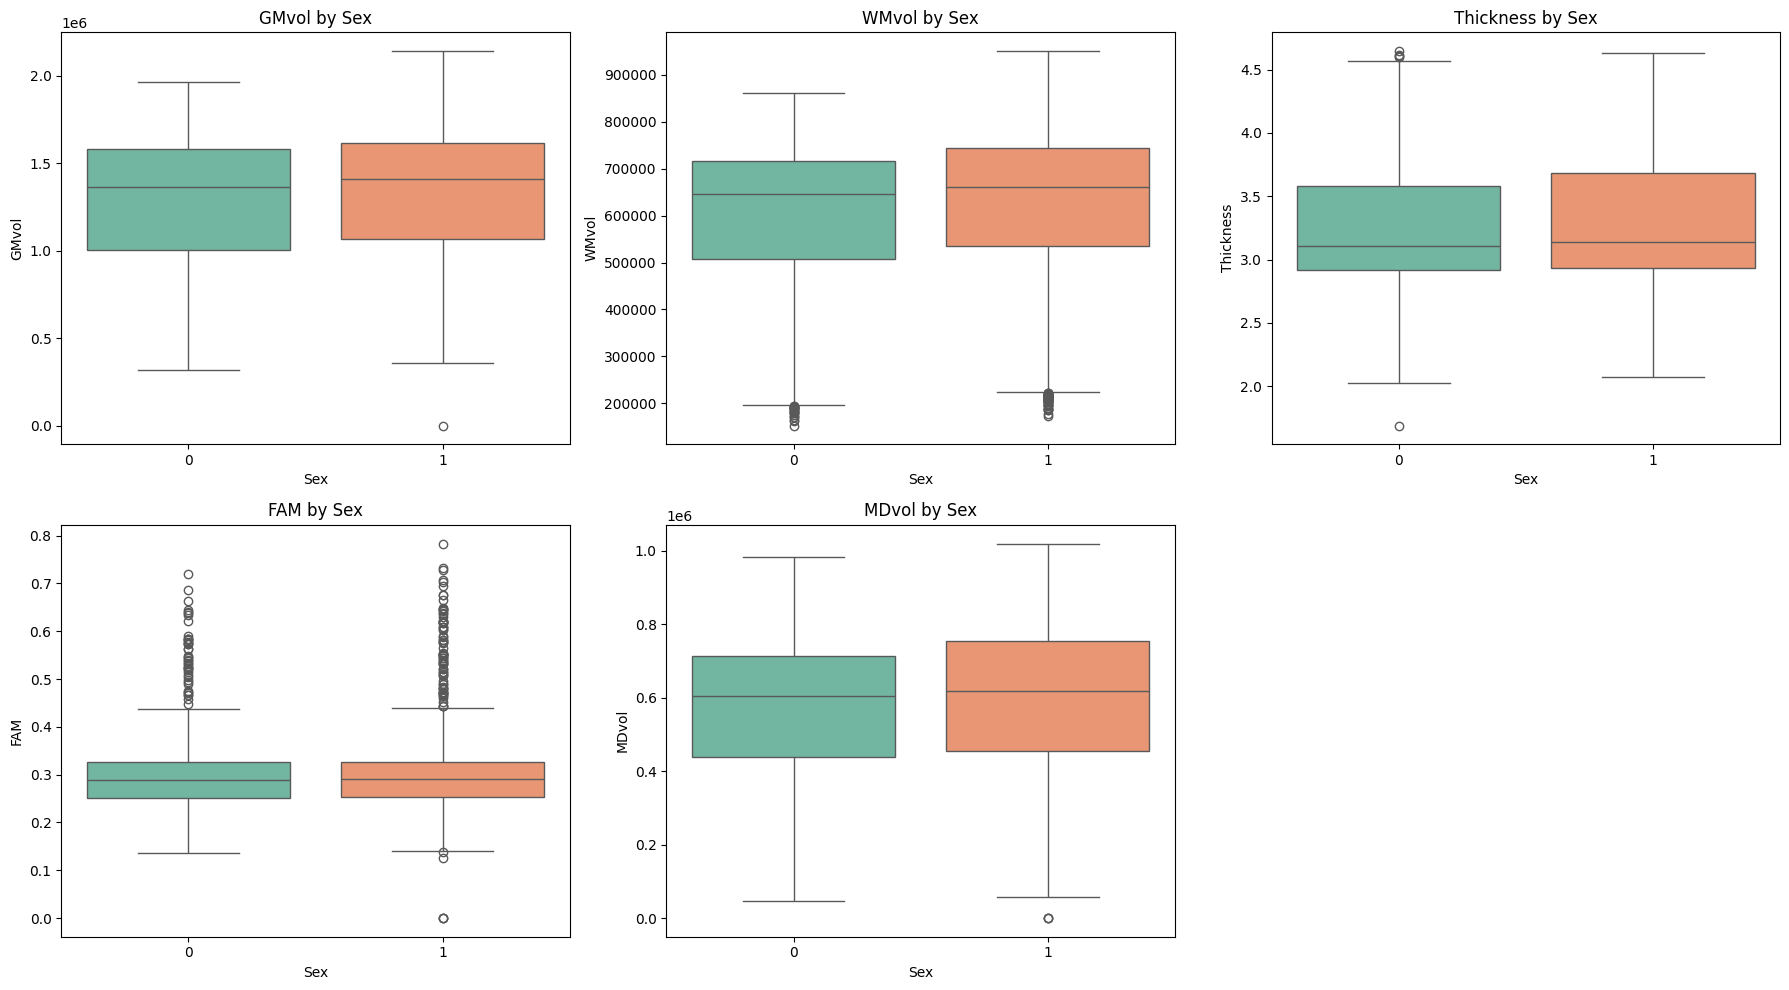

In [20]:
selected_features = ['GMvol', 'WMvol', 'Thickness', 'FAM', 'MDvol']

plt.figure(figsize=(18, 10))
for i, col in enumerate(selected_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Sex', y=col, data=df, palette='Set2')
    plt.title(f"{col} by Sex")
plt.tight_layout()
plt.show()

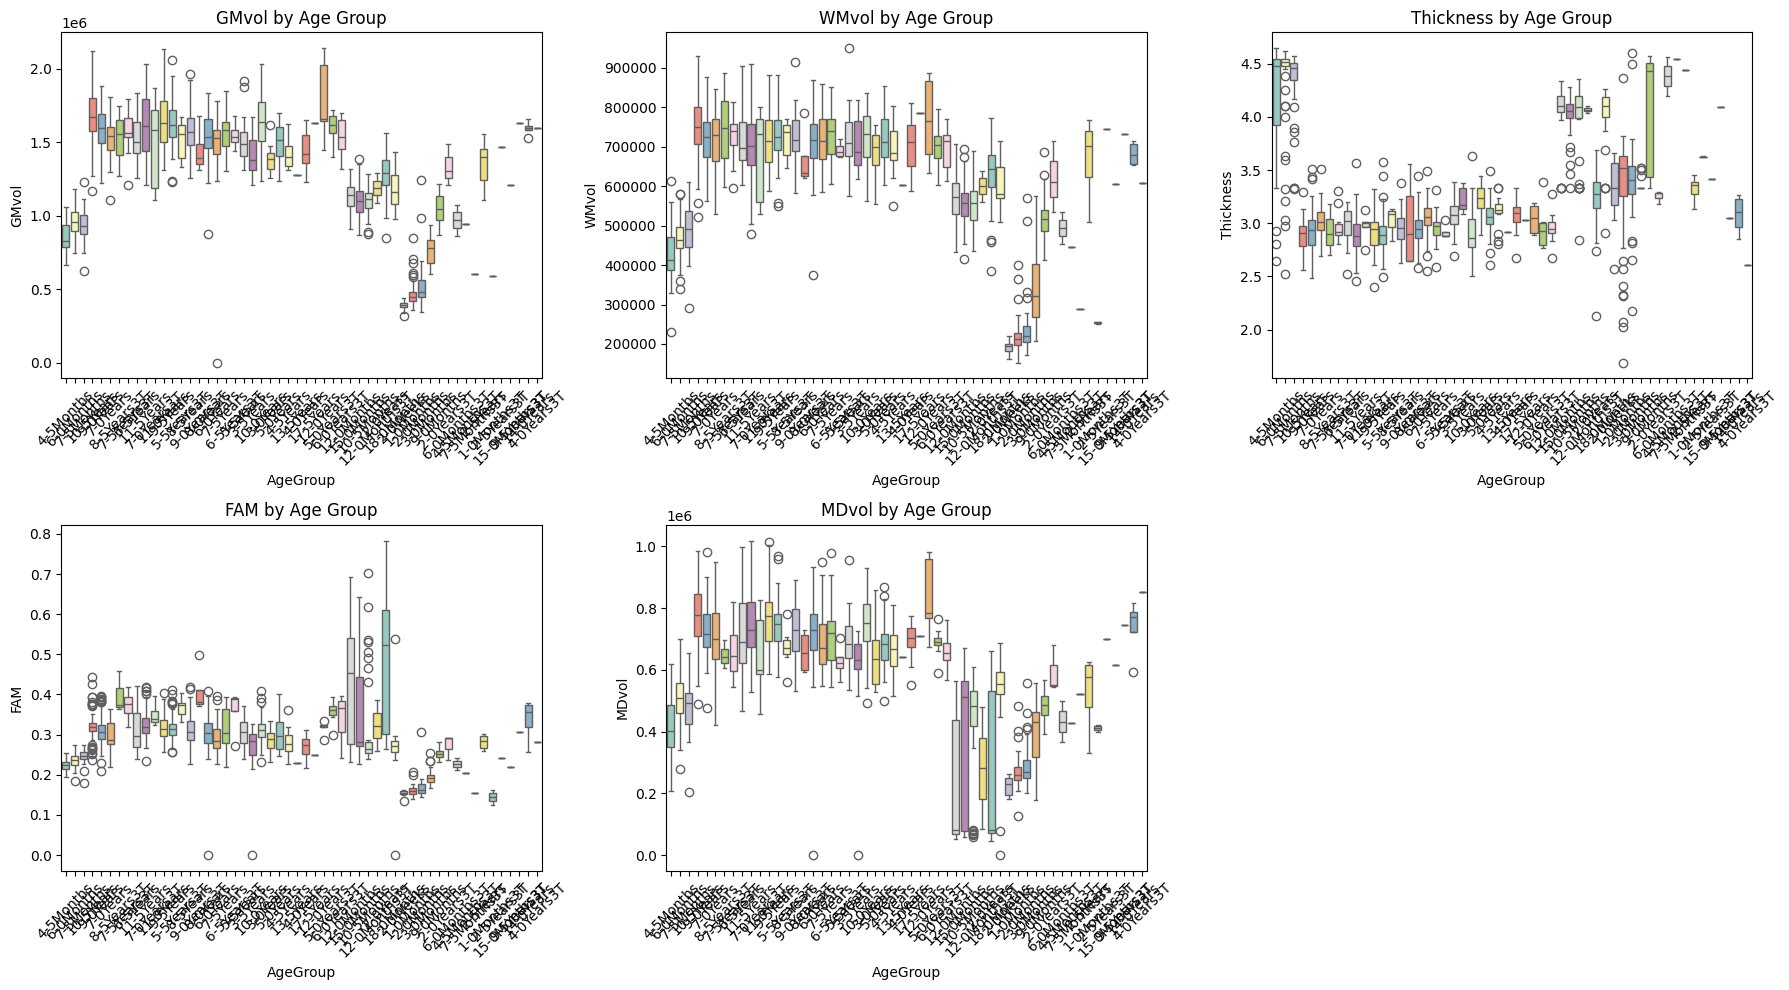

In [21]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(selected_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='AgeGroup', y=col, data=df, palette='Set3')
    plt.title(f"{col} by Age Group")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

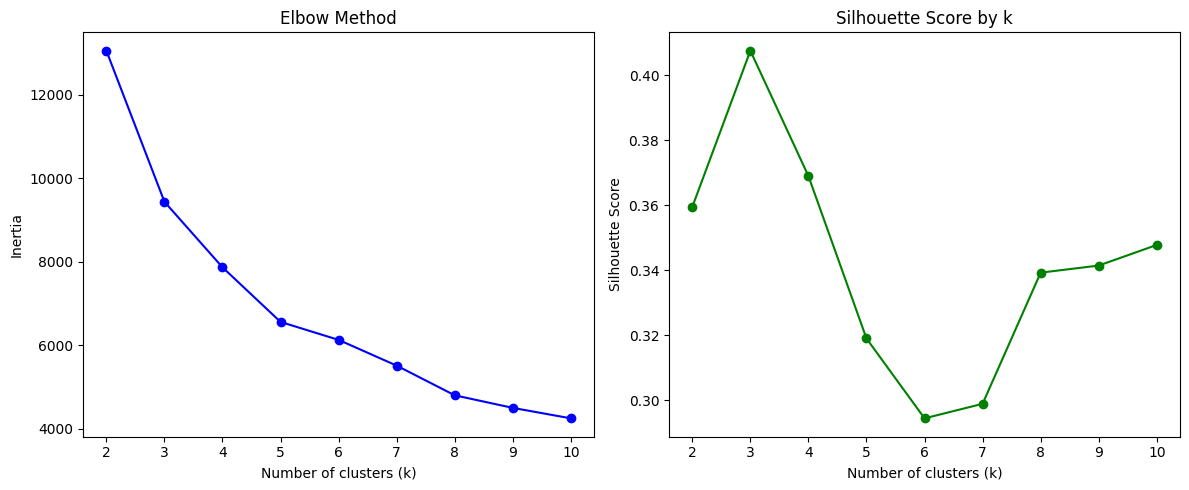

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Try k from 2 to 10
inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled_df)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_df, km.labels_))

# Plot Elbow + Silhouette
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, 'go-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')

plt.tight_layout()
plt.show()

In [23]:
# Use optimal k (e.g., k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled_df)
print(" K-Means clustering complete. Cluster counts:\n", df['KMeans_Cluster'].value_counts())

 K-Means clustering complete. Cluster counts:
 KMeans_Cluster
2    928
1    554
0    130
Name: count, dtype: int64


In [24]:
from sklearn.cluster import DBSCAN
# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  # You can tune these
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled_df)

# Cluster summary
print("DBSCAN Cluster Counts:\n", df['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster Counts:
 DBSCAN_Cluster
 3    660
 2    634
 4     84
 0     54
 5     46
 8     39
 1     27
-1     26
 6     24
 7     11
 9      7
Name: count, dtype: int64


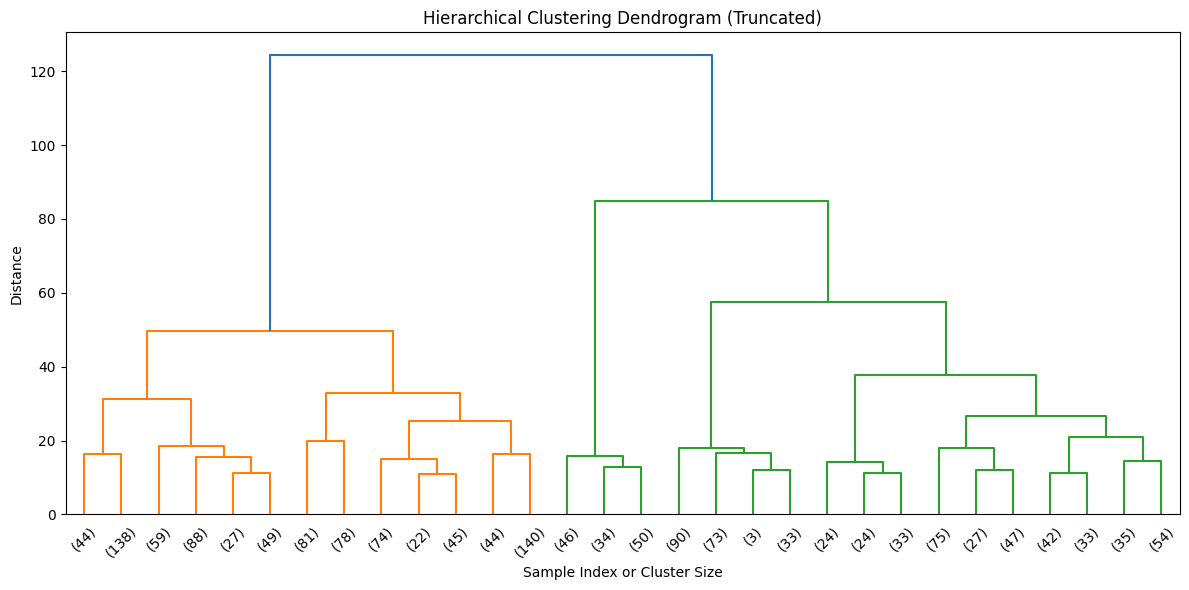

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

# Step 1: Dendrogram
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(X_scaled_df, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=45., leaf_font_size=10.)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Sample Index or Cluster Size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [26]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering (fixed version)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled_df)

print("Hierarchical Clustering done. Cluster counts:\n", df['Hierarchical_Cluster'].value_counts())

Hierarchical Clustering done. Cluster counts:
 Hierarchical_Cluster
1    889
0    593
2    130
Name: count, dtype: int64


In [27]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled_df)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['KMeans'] = df['KMeans_Cluster']
pca_df['DBSCAN'] = df['DBSCAN_Cluster']
pca_df['Hierarchical'] = df['Hierarchical_Cluster']

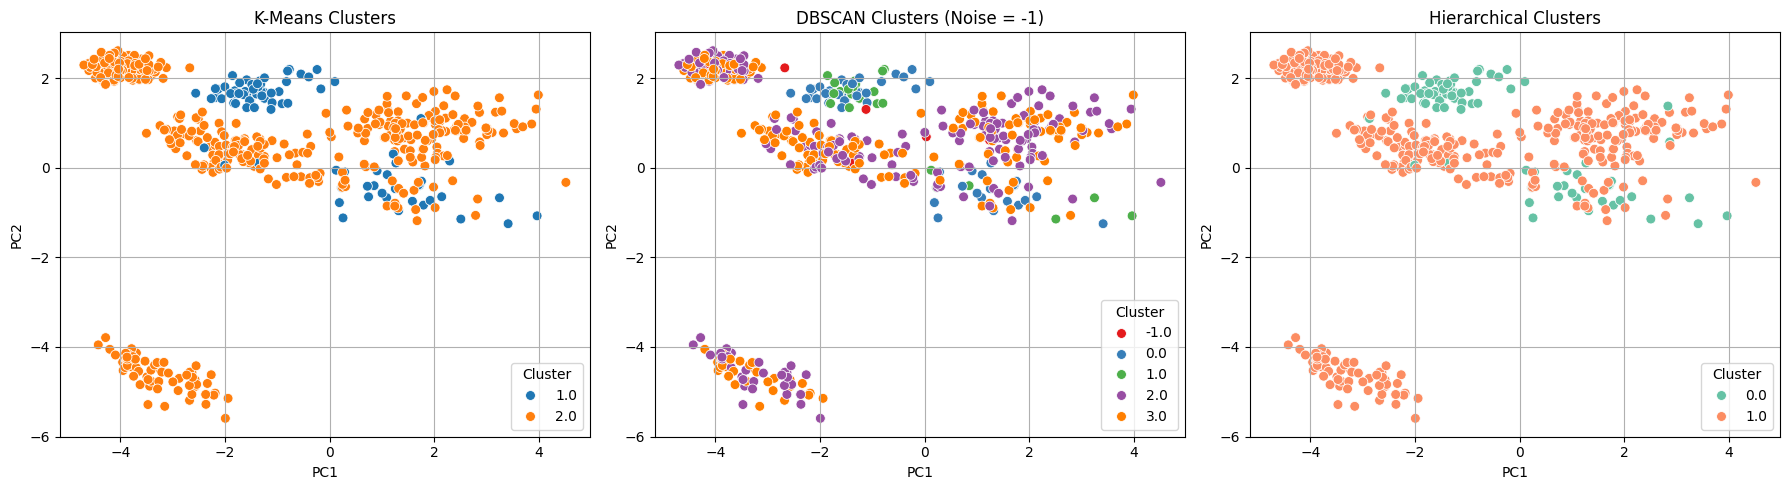

In [28]:
plt.figure(figsize=(18, 5))

# KMeans
plt.subplot(1, 3, 1)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='KMeans', palette='tab10', s=50)
plt.title('K-Means Clusters')
plt.legend(title='Cluster', loc='best')
plt.grid(True)

# DBSCAN
plt.subplot(1, 3, 2)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='DBSCAN', palette='Set1', s=50)
plt.title('DBSCAN Clusters (Noise = -1)')
plt.legend(title='Cluster', loc='best')
plt.grid(True)

# Hierarchical
plt.subplot(1, 3, 3)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Hierarchical', palette='Set2', s=50)
plt.title('Hierarchical Clusters')
plt.legend(title='Cluster', loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()


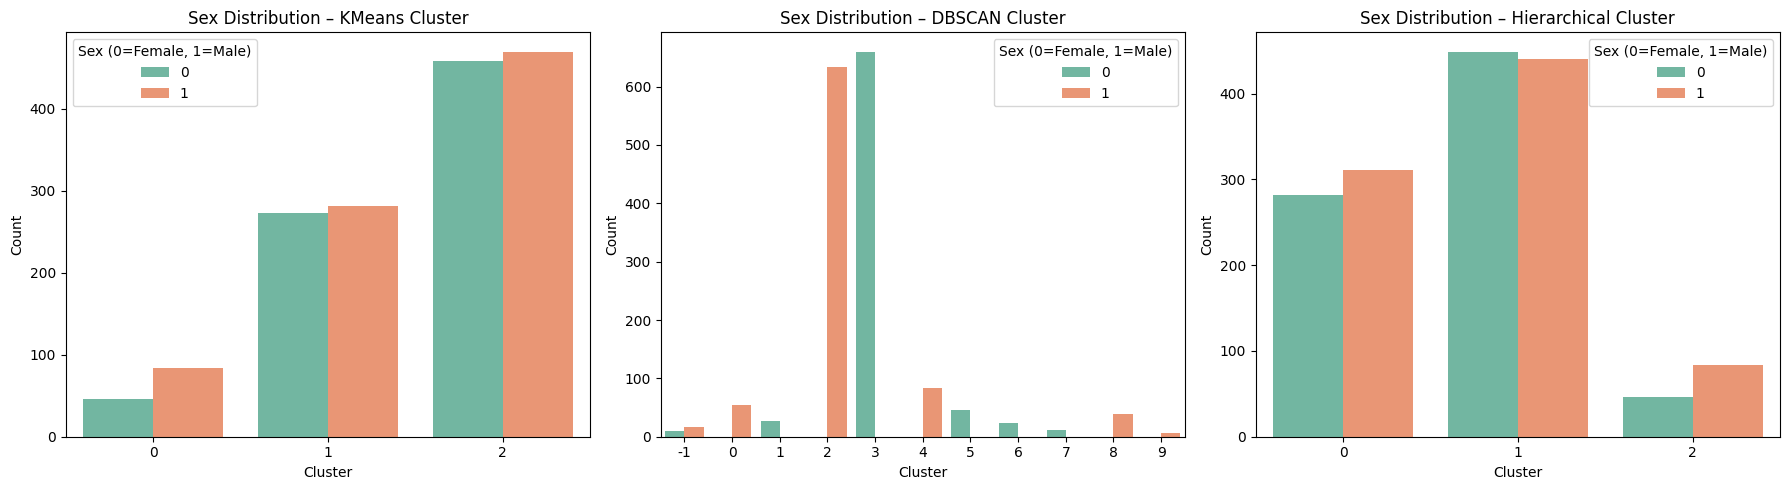

In [29]:
plt.figure(figsize=(18, 5))

for i, method in enumerate(['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster']):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=df[method], hue=df['Sex'], palette='Set2')
    plt.title(f"Sex Distribution – {method.replace('_', ' ')}")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.legend(title='Sex (0=Female, 1=Male)')

plt.tight_layout()
plt.show()

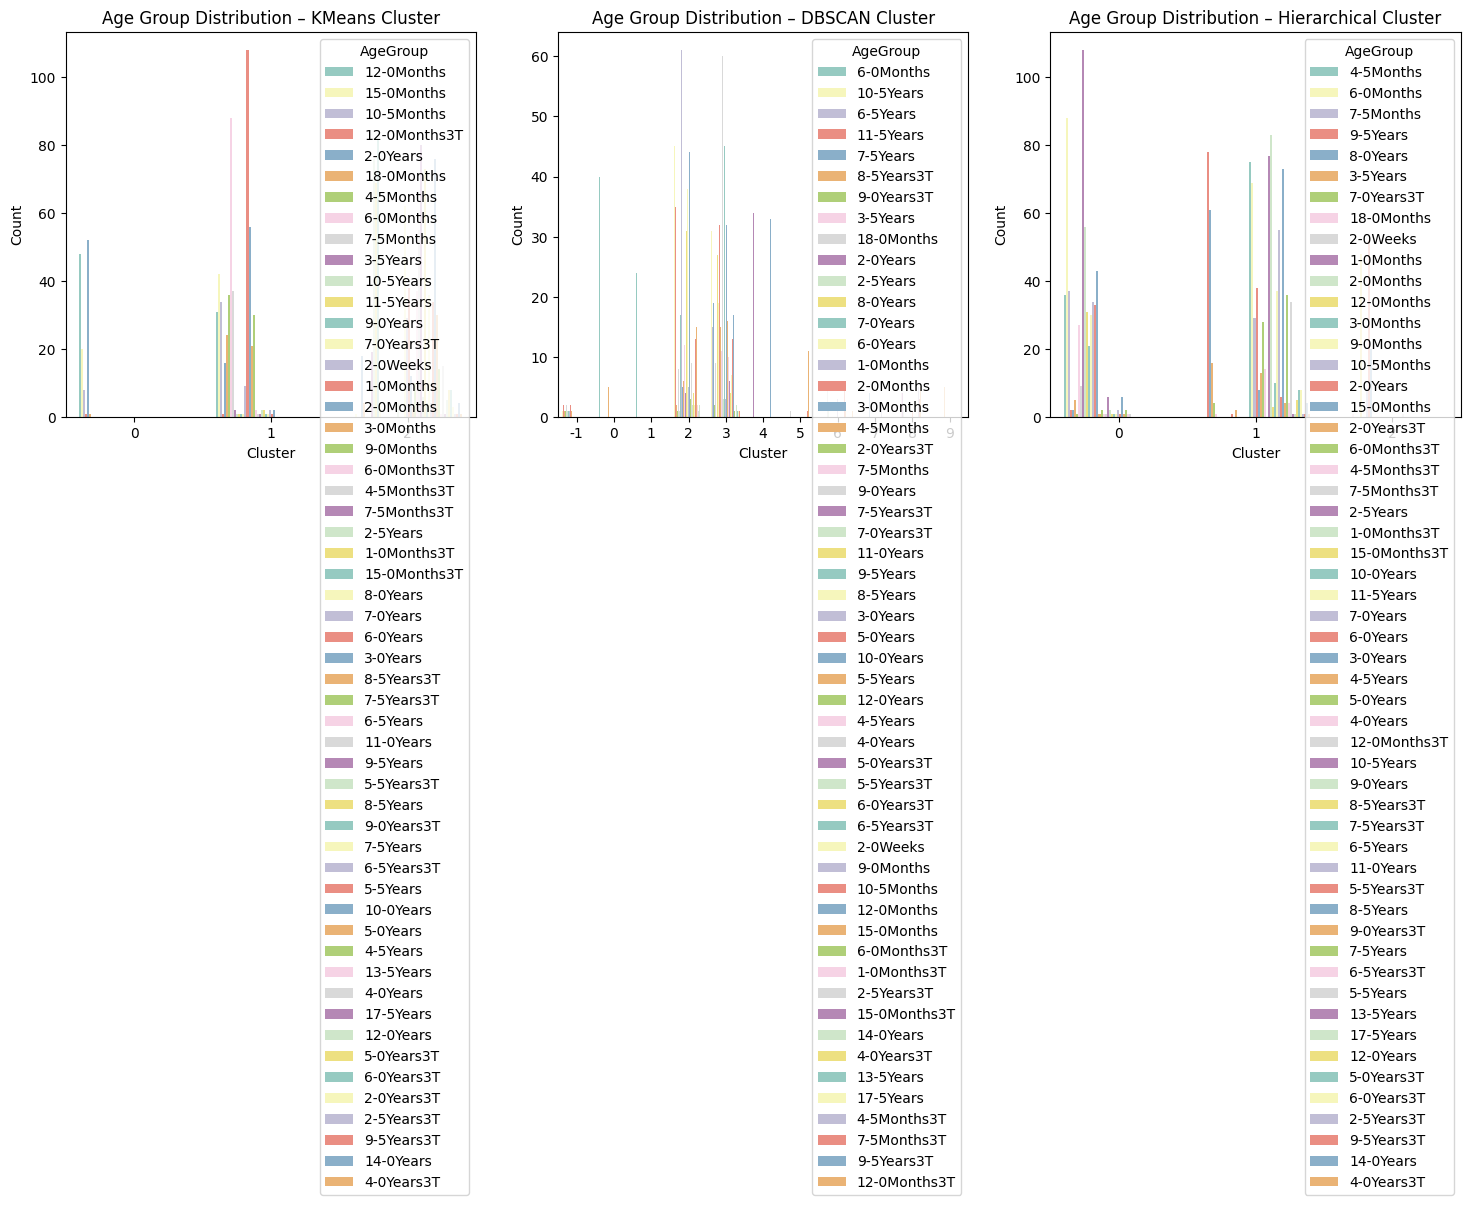

In [30]:
plt.figure(figsize=(18, 5))

for i, method in enumerate(['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster']):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=df[method], hue=df['AgeGroup'], palette='Set3')
    plt.title(f"Age Group Distribution – {method.replace('_', ' ')}")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.legend(title='AgeGroup', loc='upper right')

plt.tight_layout()
plt.show()

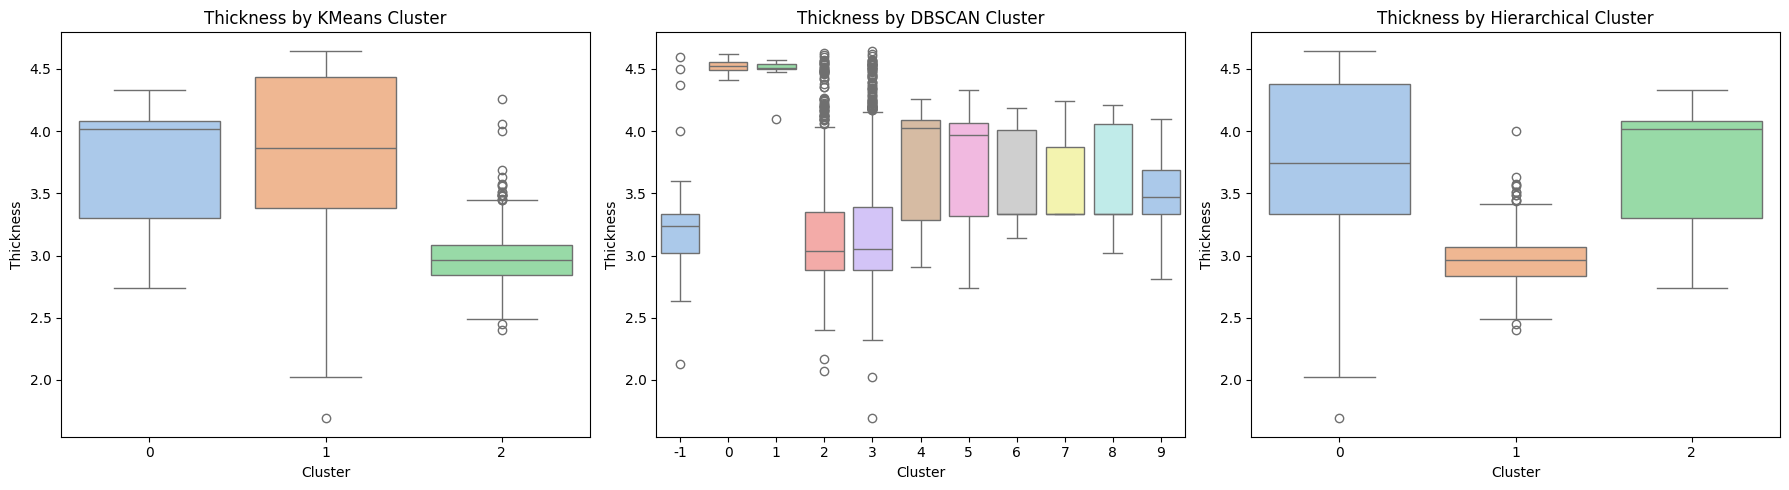

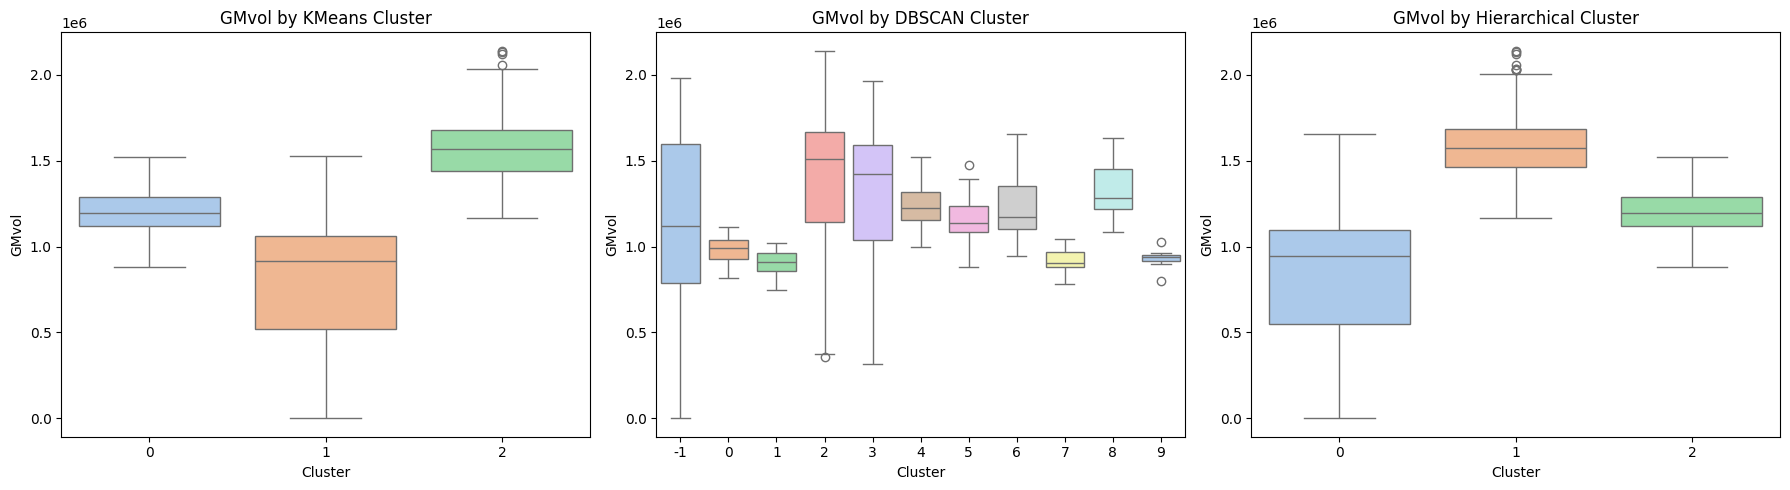

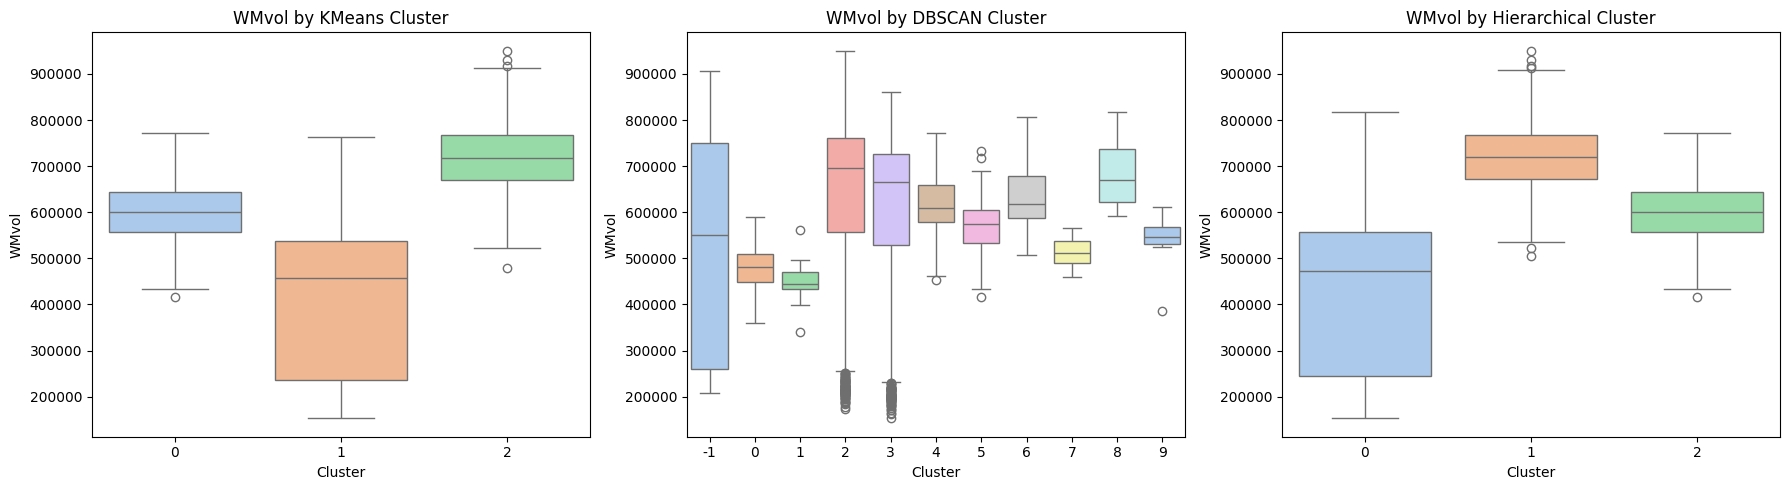

In [31]:
brain_features = ['Thickness', 'GMvol', 'WMvol']

for feature in brain_features:
    plt.figure(figsize=(18, 5))

    for i, method in enumerate(['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster']):
        plt.subplot(1, 3, i+1)
        sns.boxplot(x=df[method], y=df[feature], palette='pastel')
        plt.title(f"{feature} by {method.replace('_', ' ')}")
        plt.xlabel("Cluster")
        plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [32]:
# Count outliers (DBSCAN label -1)
outliers = df[df['DBSCAN_Cluster'] == -1]
print("🔍 Total Outliers Detected by DBSCAN:", len(outliers))

# Display summary stats for outliers
outlier_summary = outliers.describe()
display(outlier_summary)

# Compare outliers' Age and Sex
outlier_demo = outliers.groupby(['Sex', 'AgeGroup']).size().reset_index(name='Count')
print("Outlier Demographics (Sex x AgeGroup):")
display(outlier_demo)

🔍 Total Outliers Detected by DBSCAN: 26


,ID,Bvol,GMvol,WMvol,Thickness,Sex,Age,FAvol,FAM,FAPVE,MDvol,MDM,MDPVE,AgeGroupEncoded,RibbonEncoded,KMeans_Cluster,DBSCAN_Cluster,Hierarchical_Cluster
count,26.000000,26.000000,2.600000e+01,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.0,26.000000
mean,2891.961538,7452.769231,1.163772e+06,529722.402042,3.286318,0.653846,4.050989,508282.421875,0.239465,147851.818104,519347.520433,0.000668,383.549661,24.346154,863.230769,1.346154,-1.0,0.346154
std,2003.377997,4148.085460,5.116776e+05,255683.020750,0.566925,0.485165,4.149903,262610.275153,0.132929,115412.637299,258106.633504,0.000345,233.087740,14.002692,514.318680,0.485165,0.0,0.485165
min,78.000000,1947.000000,0.000000e+00,208654.809000,2.131317,0.000000,0.115000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,192.000000,1.000000,-1.0,0.000000
25%,793.000000,2885.000000,7.888742e+05,259032.028500,3.021043,0.000000,0.305000,414801.046875,0.180453,80491.677509,427475.640625,0.000562,219.741146,16.000000,373.500000,1.000000,-1.0,0.000000
50%,3902.500000,9082.000000,1.121608e+06,549584.894000,3.238686,1.000000,2.217000,540484.562500,0.227237,101786.087641,543953.312500,0.000715,419.216741,22.000000,863.000000,1.000000,-1.0,0.000000
75%,4788.750000,11442.750000,1.595965e+06,751065.925500,3.335111,1.000000,7.736750,627901.593750,0.287382,205517.637183,627901.593750,0.000930,496.491583,35.500000,1261.750000,2.000000,-1.0,1.000000
max,4795.000000,11875.000000,1.981559e+06,906070.188000,4.599865,1.000000,11.884000,969509.000000,0.498964,371799.126016,977813.562500,0.001200,1131.605850,51.000000,1610.000000,2.000000,-1.0,1.000000


Outlier Demographics (Sex x AgeGroup):


,Sex,AgeGroup,Count
0,0,11-5Years,1
1,0,18-0Months,1
2,0,2-0Months,1
3,0,2-0Years,1
4,0,2-0Years3T,1
5,0,3-0Months,2
6,0,4-5Months,1
7,0,9-0Years3T,1
8,1,1-0Months,1
9,1,10-5Years,1


In [33]:
outlier_demo.shape

(23, 3)